In [49]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error



In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error



In [51]:
df = pd.read_csv('NIFTY_50_5_Years_cleaned.csv')
df=pd.DataFrame(df)
print(df.head())

         Date     Close      High       Low      Open  Volume
0  2021-08-09  16258.25  16320.75  16179.05  16281.35  240500
1  2021-08-10  16280.10  16359.25  16202.25  16274.80  288000
2  2021-08-11  16282.25  16338.75  16162.55  16327.30  277900
3  2021-08-12  16364.40  16375.50  16286.90  16303.65  280200
4  2021-08-13  16529.10  16543.60  16376.30  16385.70  321900


In [52]:
print(len(df))

1235


In [53]:
df.shape

(1235, 6)

In [54]:
print(df.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [55]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [56]:
X = df[["Open", "High", "Low", "Volume"]]

y = df["Close"]

In [57]:
print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
       Open      High       Low  Volume
0  16281.35  16320.75  16179.05  240500
1  16274.80  16359.25  16202.25  288000
2  16327.30  16338.75  16162.55  277900
3  16303.65  16375.50  16286.90  280200
4  16385.70  16543.60  16376.30  321900

y:
0    16258.25
1    16280.10
2    16282.25
3    16364.40
4    16529.10
Name: Close, dtype: float64


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)



In [59]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [60]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-7352.76,10082.53, 8172.5 , -13.58]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.531e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[16.41, 2.7 , 0.23, 0.17]"


In [61]:
regression_model.intercept_

np.float64(15310.128529694199)

In [62]:
regression_model.coef_

array([-7352.76226348, 10082.5320397 ,  8172.50047629,   -13.57735704])

In [63]:
y_pred_train = regression_model.predict(X_train)

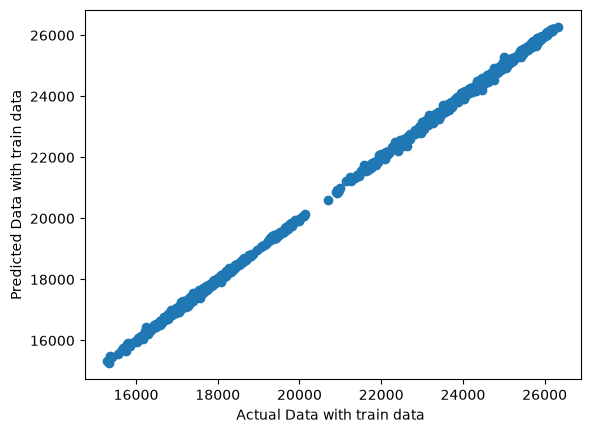

In [64]:
plt.scatter(y_train,y_pred_train)
plt.xlabel("Actual Data with train data ")
plt.ylabel("Predicted Data with train data")
plt.show()

In [65]:
y_pred = regression_model.predict(X_test)

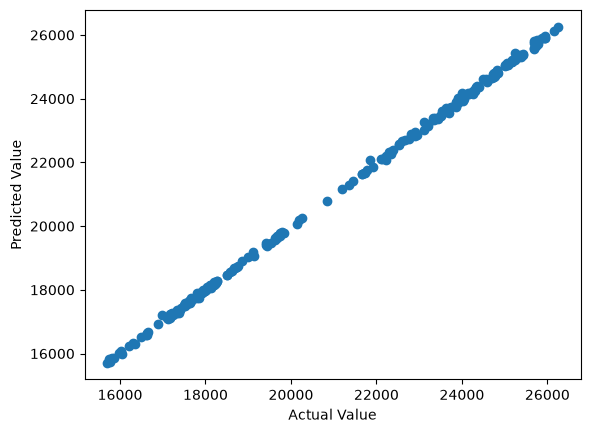

In [66]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.show()

In [67]:
mean_squared_error(y_test, y_pred)

3154.638496810379

In [68]:
# from numpy import math
# math.sqrt(mean_squared_error(y_train, y_pred_train))

In [69]:
r2_score(y_train, y_pred_train)

0.9997051542649065

In [70]:
r2_score(y_test, y_pred)

0.9997058109907009

In [71]:
results = pd.DataFrame({"Actual_Close": y_test.values,"Predicted_Close": y_pred})

print(results.head(10))

   Actual_Close  Predicted_Close
0      25052.35     25058.427163
1      21182.70     21166.530723
2      19122.15     19178.871391
3      17757.00     17735.152274
4      17171.95     17236.835087
5      17624.45     17637.303822
6      18202.80     18137.569952
7      25083.75     25073.631638
8      17624.05     17658.307959
9      25879.15     25912.443369


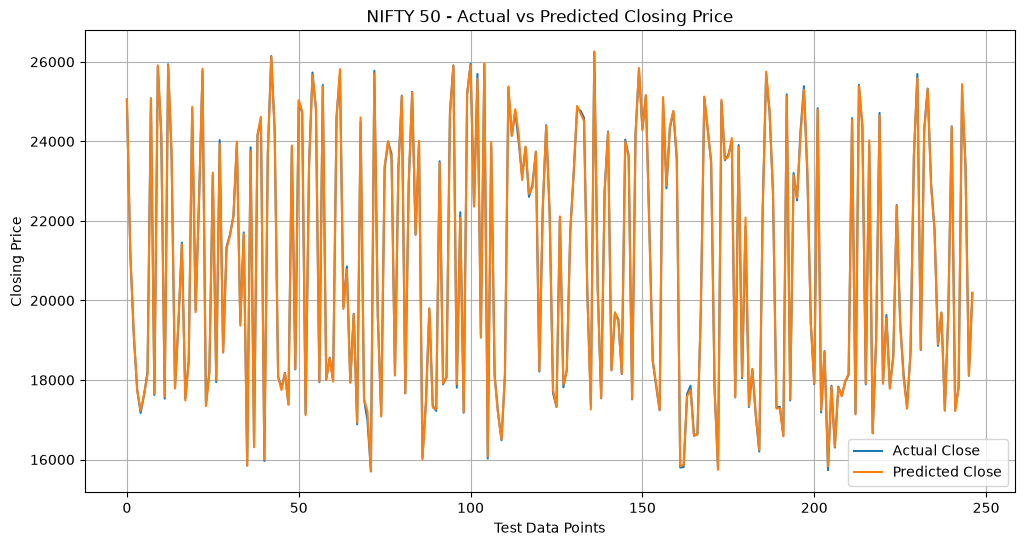

In [72]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values,label="Actual Close")

plt.plot(y_pred,label="Predicted Close")

plt.title("NIFTY 50 - Actual vs Predicted Closing Price")
plt.xlabel("Test Data Points")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

In [73]:
df["Tomorrow_Close"] = df["Close"].shift(-1)
df = df.dropna()
X = df[["Open", "High", "Low", "Close", "Volume"]]

y = df["Tomorrow_Close"]
print(df.head())


         Date     Close      High       Low      Open  Volume  Tomorrow_Close
0  2021-08-09  16258.25  16320.75  16179.05  16281.35  240500        16280.10
1  2021-08-10  16280.10  16359.25  16202.25  16274.80  288000        16282.25
2  2021-08-11  16282.25  16338.75  16162.55  16327.30  277900        16364.40
3  2021-08-12  16364.40  16375.50  16286.90  16303.65  280200        16529.10
4  2021-08-13  16529.10  16543.60  16376.30  16385.70  321900        16563.05


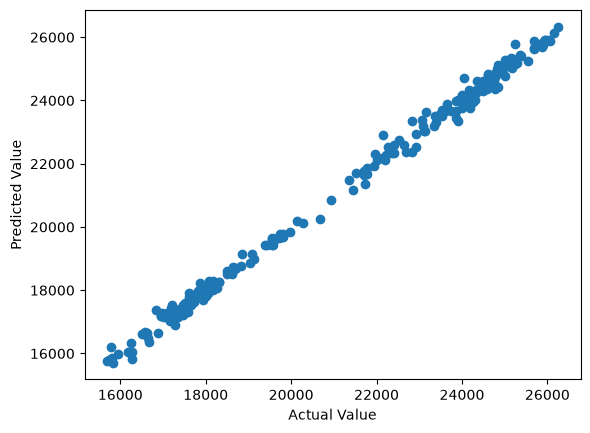

In [74]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

y_pred = regression_model.predict(X_test)

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.show()

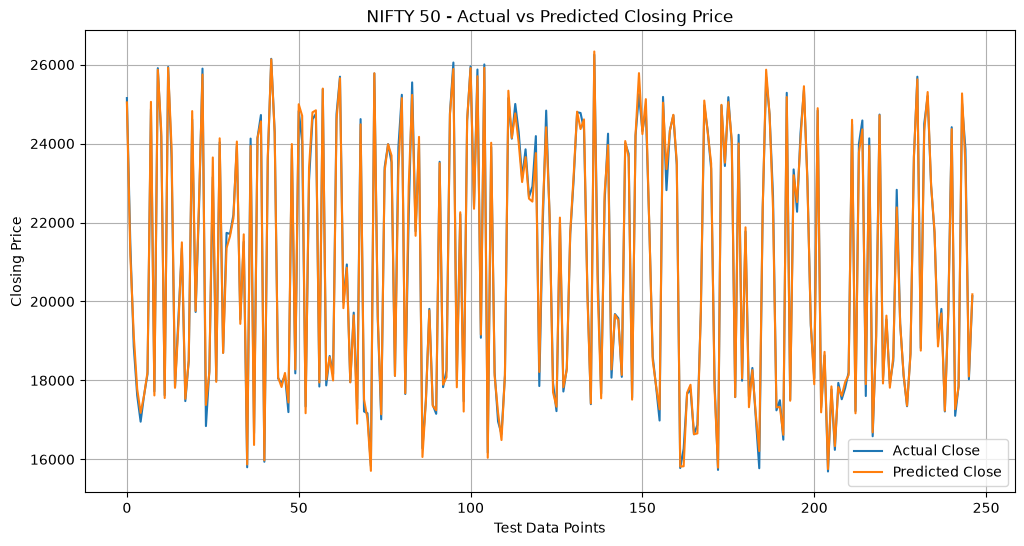

In [75]:

plt.figure(figsize=(12, 6))

plt.plot(y_test.values,label="Actual Close")

plt.plot(y_pred,label="Predicted Close")

plt.title("NIFTY 50 - Actual vs Predicted Closing Price")
plt.xlabel("Test Data Points")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

In [88]:

print(df.head())
# print( y_test.head())

         Date     Close      High       Low      Open  Volume  Tomorrow_Close
0  2021-08-09  16258.25  16320.75  16179.05  16281.35  240500        16280.10
1  2021-08-10  16280.10  16359.25  16202.25  16274.80  288000        16282.25
2  2021-08-11  16282.25  16338.75  16162.55  16327.30  277900        16364.40
3  2021-08-12  16364.40  16375.50  16286.90  16303.65  280200        16529.10
4  2021-08-13  16529.10  16543.60  16376.30  16385.70  321900        16563.05


In [84]:
results = pd.DataFrame({"Actual_Close": y_test.values,"Predicted_Close": y_pred})

print(results.head(10))

   Actual_Close  Predicted_Close
0      25151.95     25042.215760
1      21456.65     21179.218945
2      18857.25     19138.217565
3      17617.15     17781.157655
4      16953.95     17177.574496
5      17624.05     17620.303398
6      18157.00     18213.886951
7      24870.10     25057.500521
8      17722.30     17618.802778
9      25910.05     25869.664779


In [78]:
r2_score(y_test, y_pred)

0.9967233037700969

In [79]:
mean_squared_error(y_test, y_pred)

34926.47522424755

In [80]:
mean_absolute_error(y_test,y_pred)

137.11452548305843

In [81]:
root_mean_squared_error(y_test,y_pred)

186.88626280239956

In [82]:
mean_absolute_percentage_error(y_test,y_pred)

0.006615954803901743